```python

from timex.ecg import ECGxtract

ecg_extractor = ECGxtract(data_location='/path/to/data', leads=['I', 'II',..], id_names=['ID'], iterative=True, sampling_rate=1000)

ecg_segments = ecg_extractor.extract_segments()
ecg_rates = ecg_extractor.extract_rates()
ecg_timings = ecg_extractor.extract_timings(ecg_segments)
ecg_cwt = ecg_extractor.extract_cwt(ecg_segments)
ecg_dwt = ecg_extractor.extract_dwt(ecg_segments)
ecg_ft = ecg_extractor.extract_ft(ecg_segments)
```

In [274]:
# add autoreload
%load_ext autoreload
%autoreload 2
import neurokit2 as nk
import numpy as np
from scipy.stats.mstats import gmean
import pandas as pd
import wfdb
import os
import sys
import re
import dotenv
from collections import defaultdict
from tqdm import tqdm

from typing import List, Tuple

from timex.ecg import extractor
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
dotenv.load_dotenv('../.env')

True

In [9]:
BASE_DIR = os.getenv('ECG_DIR')
HEA_DIR = os.path.join(BASE_DIR,
                       'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
                       'records500',
                       '00000')

SAMPLE_RATE = 500

In [10]:
HEA_DIR

'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000'

In [11]:
hea_list = [os.path.join(HEA_DIR, f.split('.')[0]) 
            for f in os.listdir(HEA_DIR) if f.endswith('.hea')]

In [15]:
ecg_path = r'T:\laupodteam\AIOS\Bram\data\ECG\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\records500\00000\00001_hr' # hea_list[5]
hea = os.path.basename(ecg_path)

band_names = wfdb.rdheader(ecg_path).__dict__['sig_name']
record = wfdb.rdrecord(ecg_path)
meta_str = ",".join(wfdb.rdheader(ecg_path).__dict__['comments'])

In [19]:
record.__dict__['comments'], meta_str

([], '')

In [20]:
wfdb.rdrecord(ecg_path).fs

500

In [ ]:
tmp = wfdb.rdsamp(ecg_path)[0]
tdf = pd.DataFrame(tmp, columns=band_names)

In [152]:
band_names

['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

In [193]:
BAND = 'II'

In [194]:
cleaned_signal_processed, r_peaks  = nk.ecg_process(tdf[BAND], sampling_rate=SAMPLE_RATE)
cleaned_signal = nk.ecg_clean(tdf[BAND], sampling_rate=SAMPLE_RATE)

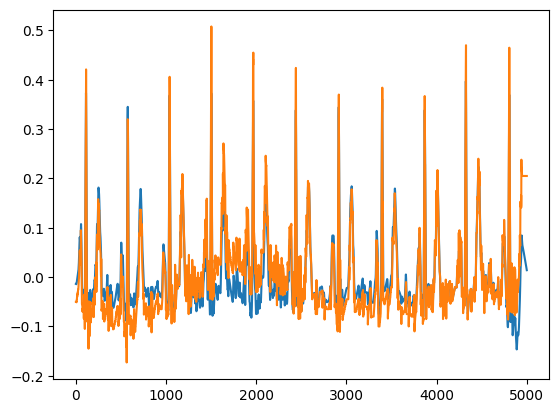

In [195]:
filtered_signal = nk.signal_filter(tdf[BAND], sampling_rate=SAMPLE_RATE, lowcut=0.5, highcut=40, order=2)
plt.plot(filtered_signal)
plt.plot(tdf[BAND])

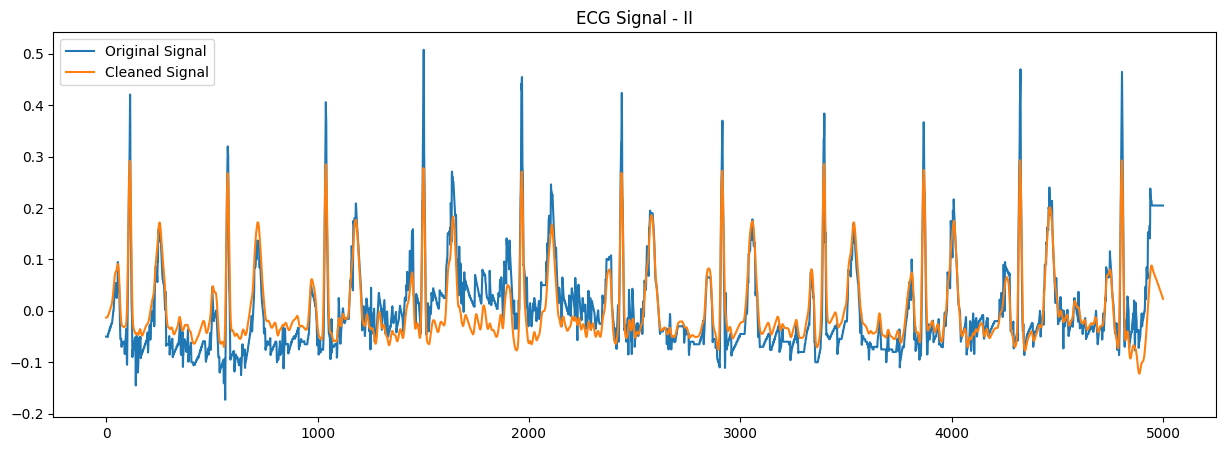

In [196]:
plt.figure(figsize=(15, 5))
plt.plot(tdf[BAND], label='Original Signal')
plt.plot(cleaned_signal, label='Cleaned Signal')
plt.title(f"ECG Signal - {BAND}")
plt.legend()

In [198]:
peaks, peaks_info = nk.ecg_peaks(cleaned_signal, sampling_rate=SAMPLE_RATE)

peak_features_time = nk.hrv_time(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, 
                                 show=False).to_dict(orient='index')[0]

peak_features_nonlinear = nk.hrv_nonlinear(peaks_info['ECG_R_Peaks'], 
                                           sampling_rate=SAMPLE_RATE, 
                                           show=False).to_dict(orient='index')[0]

peak_features_frequency = nk.hrv_frequency(peaks_info['ECG_R_Peaks'], sampling_rate=SAMPLE_RATE, show=False, 
                                           normalize=True).to_dict(orient='index')[0]
                                        

In [199]:
signals, _ = nk.ecg_process(cleaned_signal, sampling_rate=500)
hr_features = nk.ecg_intervalrelated(signals)
hr_features = {k: np.array(v).flatten()[0] for k,v in hr_features.to_dict(orient='index')[0].items()}

In [200]:
len(hr_features), len(peak_features_time), len(peak_features_nonlinear), len(peak_features_frequency)

(76, 25, 40, 10)

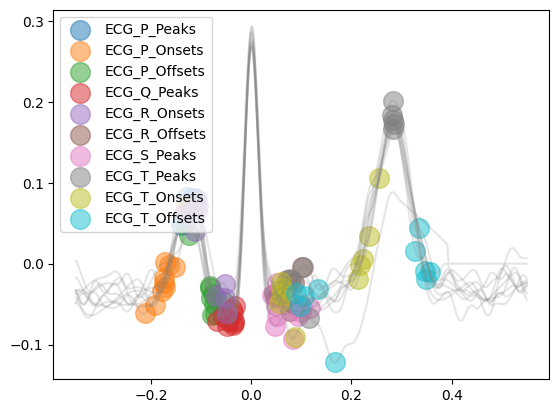

In [201]:
_, waves_peak = nk.ecg_delineate(cleaned_signal, 
                                 peaks_info, 
                                 sampling_rate=SAMPLE_RATE, 
                                 method="dwt",
                                 show=True,
                                 show_type='all')

In [190]:
waves_peak

{'ECG_P_Peaks': [503, 978, 1447, 1902, 2382, 2852, 3339, 3810, 4226, 4749],
 'ECG_P_Onsets': [491, 952, 1430, 1878, 2360, 2834, 3322, 3793, 4219, 4719],
 'ECG_P_Offsets': [510, 1006, 1460, 1924, 2401, 2876, 3358, 3830, 4238, 4784],
 'ECG_Q_Peaks': [np.int64(557),
  np.int64(1021),
  np.int64(1484),
  np.int64(1949),
  np.int64(2415),
  np.int64(2896),
  np.int64(3364),
  np.int64(3848),
  np.int64(4301),
  np.int64(4787)],
 'ECG_R_Onsets': [548, 1015, 1472, 1904, 2383, 2854, 3343, 3839, 4290, 4753],
 'ECG_R_Offsets': [597, 1063, 1543, 2006, 2471, 2949, 3446, 3907, 4367, 4831],
 'ECG_S_Peaks': [np.int64(640),
  np.int64(1087),
  np.int64(1523),
  np.int64(1999),
  np.int64(2461),
  np.int64(2966),
  np.int64(3463),
  np.int64(3887),
  np.int64(4347),
  np.int64(4845)],
 'ECG_T_Peaks': [718, 1103, 1545, 2028, 2473, 2949, 3447, 3909, 4373, 4862],
 'ECG_T_Onsets': [695, 1091, 1533, 2017, 2463, 2943, 3428, 3894, 4350, 4847],
 'ECG_T_Offsets': [745, 1112, 1565, 2044, 2481, 2964, 3462, 3920, 

In [348]:
def find_flat_regions(ts: np.ndarray, flatten_order=20, mean='geometric')-> List[Tuple[int,int]]:
    """
        given a timeseries, find the flat regions, indicated with index-tuples
    """

    ddlist = []
    for k in range(1,flatten_order+1):
        ddlist.append(np.diff(ts, k, append=[np.nan]*k))
    stacked = np.vstack(ddlist)
    if mean=='arithmetic':
        _mean = np.nanmean(stacked[:,:-flatten_order], axis=0)
    elif mean=='geometric':
        _mean = gmean(np.abs(stacked[:,:-flatten_order]), axis=0, nan_policy='omit')
    
    return np.convolve(_mean, np.ones(flatten_order-1), mode='same')

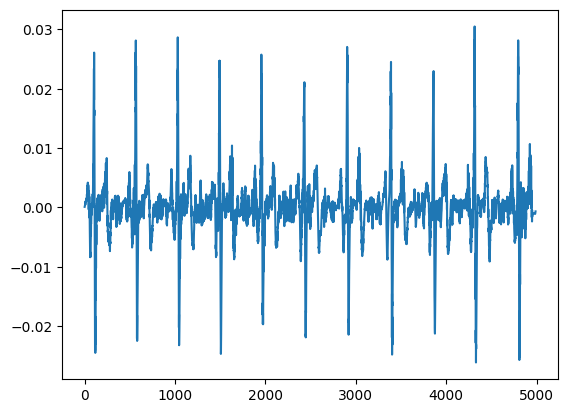

In [369]:
plt.plot(find_flat_regions(cleaned_signal, flatten_order=11, mean='arithmetic'));

In [ ]:
## Durations 
#############
PtP = np.diff(waves_peak['ECG_P_Peaks'])/SAMPLE_RATE
Pduration = np.subtract(waves_peak['ECG_P_Offsets'], waves_peak['ECG_P_Onsets'])/SAMPLE_RATE

QtQ = np.diff(waves_peak['ECG_Q_Peaks'])/SAMPLE_RATE

RtRon = np.diff(waves_peak['ECG_R_Onsets'])/SAMPLE_RATE
RtRoff = np.diff(waves_peak['ECG_R_Offsets'])/SAMPLE_RATE
Rduration = np.subtract(waves_peak['ECG_R_Offsets'], waves_peak['ECG_R_Onsets'])/SAMPLE_RATE

StS = np.diff(waves_peak['ECG_S_Peaks'])/SAMPLE_RATE

TtT = np.diff(waves_peak['ECG_T_Peaks'])/SAMPLE_RATE
Tduration = np.subtract(waves_peak['ECG_T_Offsets'], waves_peak['ECG_T_Onsets'])/SAMPLE_RATE

QRSduration = np.subtract(waves_peak['ECG_S_Peaks'], waves_peak['ECG_Q_Peaks'])/SAMPLE_RATE


## Elevations and depressions
###############
ECG_S_Peaks = np.array(waves_peak['ECG_R_Offsets'])
ECG_S_Peaks= ECG_S_Peaks[~np.isnan(ECG_S_Peaks)].astype(int)
    
S_peak_mean = np.mean(cleaned_signal[ECG_S_Peaks])
S_peak_std = np.std(cleaned_signal[ECG_S_Peaks])

ECG_R_Offsets = np.array(waves_peak['ECG_R_Offsets'])
ECG_R_Offsets= ECG_R_Offsets[~np.isnan(ECG_R_Offsets)].astype(int)
                         
R_offset_mean = np.mean(cleaned_signal[ECG_R_Offsets])
R_offset_std = np.std(cleaned_signal[ECG_R_Offsets])

ECG_T_Onsets = np.array(waves_peak['ECG_T_Onsets'])
ECG_T_Onsets= ECG_T_Onsets[~np.isnan(ECG_T_Onsets)].astype(int)
       
T_onset_mean = np.mean(cleaned_signal[ECG_T_Onsets])
T_onset_std = np.std(cleaned_signal[ECG_T_Onsets])



# STdepression
# STelevation
# T_wave_inversion


In [ ]:
# Unacceptable, Barely acceptable, Excellent
quality_string = nk.ecg_quality(cleaned_signal, 
                                rpeaks=peaks, 
                                method='zhao2018',
                                approach='fuzzy',
                                sampling_rate=SAMPLE_RATE)

# Unacceptable, Barely acceptable, Excellent
quality_score = nk.ecg_quality(cleaned_signal, 
                               sampling_rate=SAMPLE_RATE)

ecg_rates = nk.ecg_rate(peaks, sampling_rate=SAMPLE_RATE, desired_length=len(peaks)+1)

#ecg_rsp = nk.ecg_rsp(ecg_rates, method='sarkar2015', sampling_rate=SAMPLE_RATE)

In [113]:
np.mean(ecg_rates), np.std(ecg_rates), np.mean(quality_score)

(np.float64(63.91901112044344),
 np.float64(0.9458783272964109),
 np.float64(0.5698771254932431))

In [ ]:
ecg_rates.shape, ecg_rsp.shape, cleaned_signal.shape

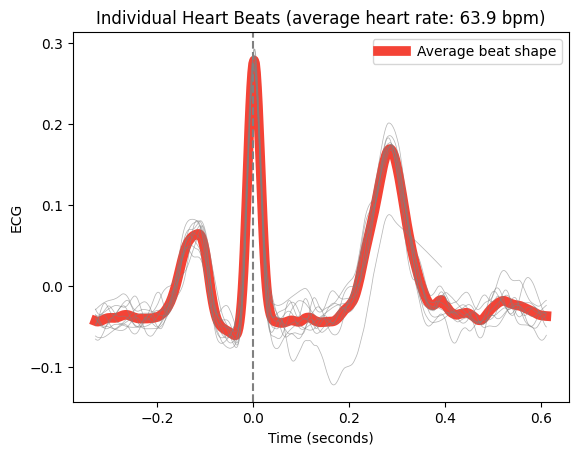

In [107]:
ecg_segmentation = nk.ecg_segment(cleaned_signal,
                                  sampling_rate=SAMPLE_RATE,
                                  show=True)

In [62]:
ecg_segmentation.keys()

dict_keys([np.str_('1'), np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('10')])

In [69]:
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))
from timex.ecg import dataset

INFO:root:Initializing Config class


In [22]:
from sklearn.preprocessing import MultiLabelBinarizer

In [71]:
ecgDS = dataset.ECGDataset(data=os.path.join(BASE_DIR,
                                       'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
                                       'records500',
                                       '00000'),
                       label_binarizer=None,
                       augmentations=[],
                       preprocessing=[])

First 5 elements of the file_list: ['T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00969_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00106_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00483_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00545_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00133_hr.hea']
No labels available to show unique values


In [72]:
res_dict = defaultdict(dict)
for i in tqdm(range(len(ecgDS))):
    r = ecgDS[i]
    res_dict[r[0]]={
        'signal': r[2],
        'label': r[3]
    }
    res_dict[r[0]].update(r[4])

100%|██████████| 987/987 [00:47<00:00, 20.86it/s]


In [34]:
_keys = list(res_dict.keys())

In [66]:
ecgExtractor = extractor.ECGxtract(sampling_rate=500, 
                             sanity_check=True,
                             extractor_groups=['wavelets', 'fcc'], 
                             extractor_type='catch22')

In [67]:
extractions = ecgExtractor.extract_from_dict(res_dict, SignalCol='signal', FsCol='fs')

NameError: name 'res_dict' is not defined

In [13]:
len(extractions.keys())

43099

In [14]:
extractions_df = pd.DataFrame(extractions).T

In [34]:
extractions_df = extractions_df.dropna(how='all')

Text(0.5, 1.0, 'Number of NaN per sample')

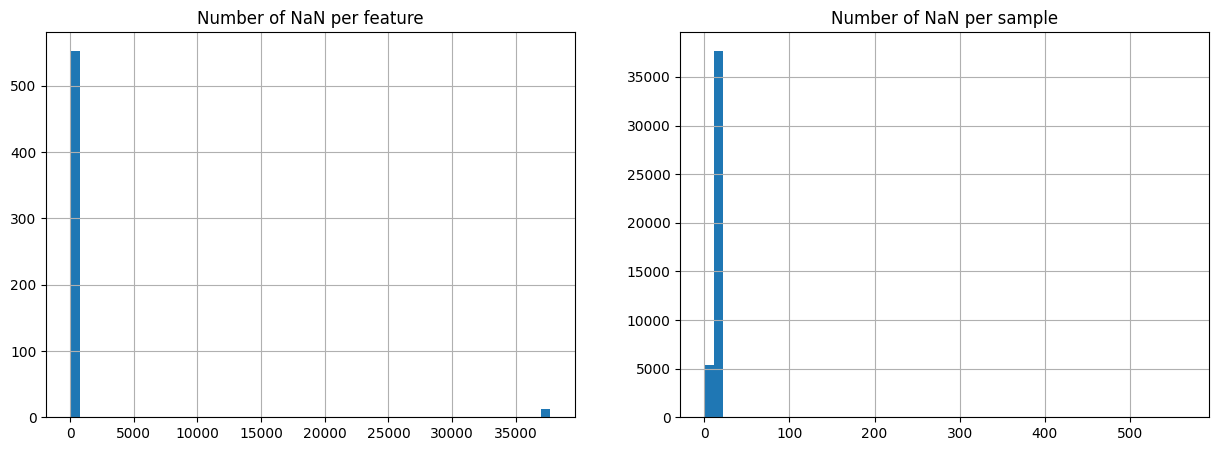

In [37]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 5))
extractions_df.isna().sum(axis=0).hist(bins=50, ax=ax[0])
extractions_df.isna().sum(axis=1).hist(bins=50, ax=ax[1])

ax[0].set_title('Number of NaN per feature')
ax[1].set_title('Number of NaN per sample')

In [13]:
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, IterativeImputer, KNNImputer
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from umap import UMAP

In [38]:
# add label and demographics
extractions_df['label'] = None
for k in _keys:
    extractions_df.loc[k, 'label'] = res_dict[k]['label']

In [11]:
VAL_COLS = [c for c in extractions_df.columns if c not in ['label', 'segment', 'fs']]

In [ ]:
extractions_df.to_parquet(os.path.join(BASE_DIR, 
                                       'physionet_classification_challenge', 
                                       'extractions_wavelets.parquet'))

In [5]:
extractions_df = pd.read_parquet(os.path.join(BASE_DIR,
                                               'physionet_classification_challenge', 
                                               'extractions_wavelets.parquet'))

In [6]:
dx_map = pd.read_csv(os.path.join(BASE_DIR, 'physionet_classification_challenge', 'Dx_map.csv'))

In [ ]:
le_pipe_euc = Pipeline([
    ('scaler', StandardScaler()),
    ('imputer', IterativeImputer(n_nearest_features=20)),
    ('pca', PCA(n_components=0.95)),
    ('umap', UMAP(n_neighbors=25, min_dist=0.1, metric='manhattan', n_components=2))
])

In [12]:
extractions_2d = le_pipe_euc.fit_transform(extractions_df[VAL_COLS].values)

/media/bramiozo/Storage1/bramiozo/VIRTUALENVS/Python/timex--LThe9rE-py3.12/lib/python3.12/site-packages/sklearn/impute/_iterative.py:825: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [41]:
extractions_2d_df = pd.DataFrame(extractions_2d, columns=['d1', 'd2'])
extractions_2d_df['label'] = extractions_df['label'].values

In [51]:
collected_labels = [ls.split(",") for ls in extractions_2d_df['label'].unique()]
label_set = set()
for ls in collected_labels:
    for l in ls:
        label_set.add(l.strip())

In [78]:
extractions_2d_df[list(label_set)] = False

In [95]:
def get_label_bool(x):
    bool_list = []
    for label in list(label_set):
        if label in x:
            bool_list.append(True)
        else:
            bool_list.append(False)
    return np.array(bool_list)

In [167]:
extractions_2d_df[list(label_set)].sum().sort_values(ascending=False)[:20]

426783006    20846
39732003      6086
164865005     6021
164934002     4673
164873001     3759
428750005     3554
164889003     3475
164951009     3389
164861001     2559
427084000     2402
59118001      2402
270492004     2394
426177001     2359
429622005     1977
164884008     1944
445118002     1806
284470004     1729
713426002     1611
111975006     1513
164930006     1475
dtype: int64

In [116]:
extractions_2d_df.loc[:, list(label_set)] = \
    np.vstack(extractions_2d_df['label'].apply(lambda x: get_label_bool(x)).tolist())

In [152]:
dx_map[dx_map['Dx'].str.contains('cardia', case=False, na=False)].head(10)

,Dx,SNOMED CT Code,Abbreviation
4,acute myocardial infarction,57054005,AMI
5,acute myocardial ischemia,413444003,AMIs
7,anterior myocardial infarction,54329005,AnMI
14,atrial tachycardia,713422000,ATach
19,bradycardia,426627000,Brady
21,cardiac dysrhythmia,698247007,CD
23,chronic myocardial ischemia,413844008,CMI
38,indeterminate cardiac axis,251200008,ICA
43,junctional tachycardia,426648003,JTach
56,myocardial infarction,164865005,MI


In [173]:
dx_map['SNOMED CT Code'] = dx_map['SNOMED CT Code'].astype(str)

In [177]:
dx_map[dx_map['SNOMED CT Code']=='164934002']

,Dx,SNOMED CT Code,Abbreviation
94,t wave abnormal,164934002,TAb


In [168]:
extractions_2d_df['39732003'].value_counts()

39732003
False    37015
True      6086
Name: count, dtype: int64

Text(0.5, 1.0, 'UMAP projection of the ECG features')

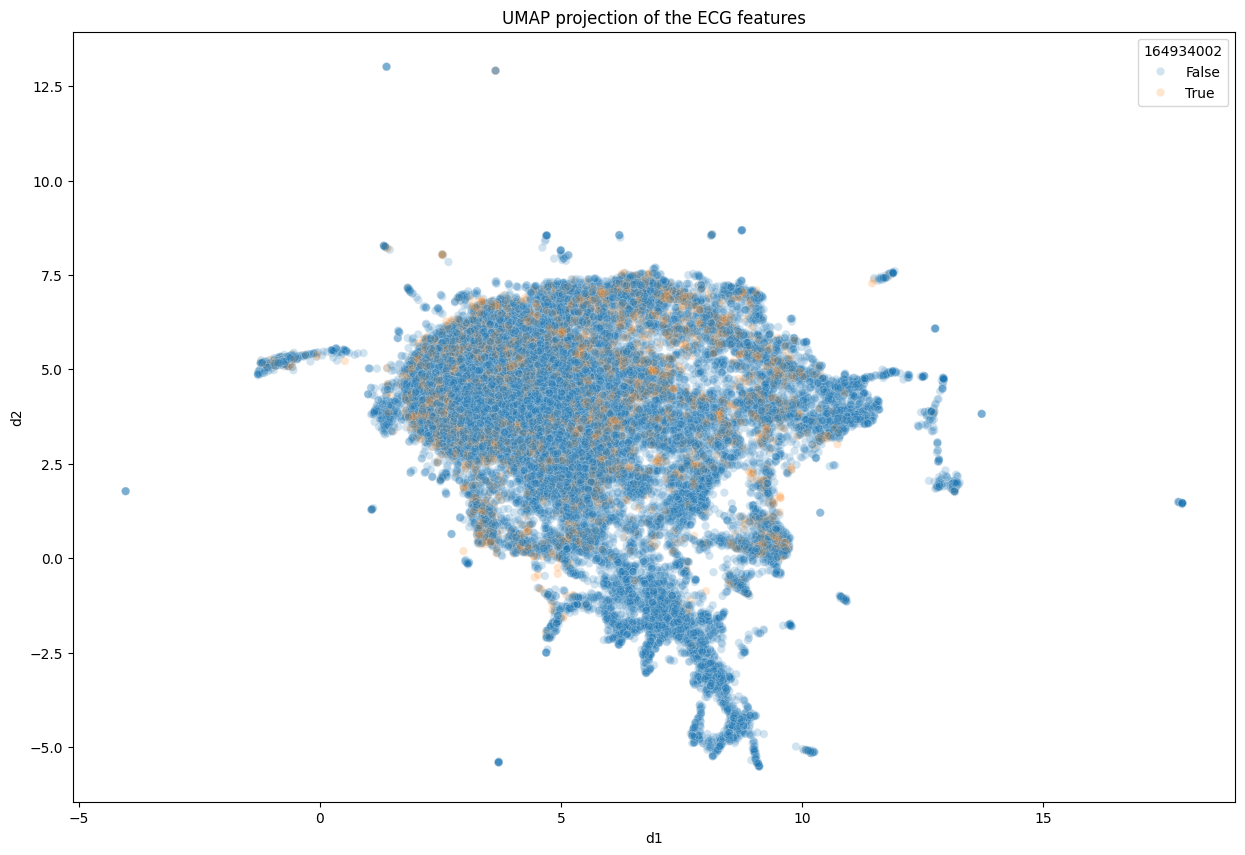

In [178]:
import seaborn as sns
plt.figure(figsize=(15, 10))
sns.scatterplot(data=extractions_2d_df, x='d1', y='d2', hue='164934002', alpha=0.2, hue_order=[False, True])
plt.title('UMAP projection of the ECG features')